In [3]:
## Load and inspect the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Social_media_impact_on_life.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Overall_Impact"].value_counts())

Dataset shape: (4500, 16)


,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial



Data types:
Student_ID                      object
Age                              int64
Gender                          object
Academic_Level                  object
Primary_Platform                object
Daily_Usage_Hours              float64
Weekend_Extra_Hours            float64
Device_Type                     object
Sleep_Duration_Hours           float64
Sleep_Quality_Score              int64
Late_Night_Usage                  bool
Social_Comparison_Frequency     object
Perceived_Stress_Score         float64
Mental_Health_Index              int64
Academic_Performance_GPA       float64
Overall_Impact                  object
dtype: object

Missing values:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score       

Exploratory data analysis

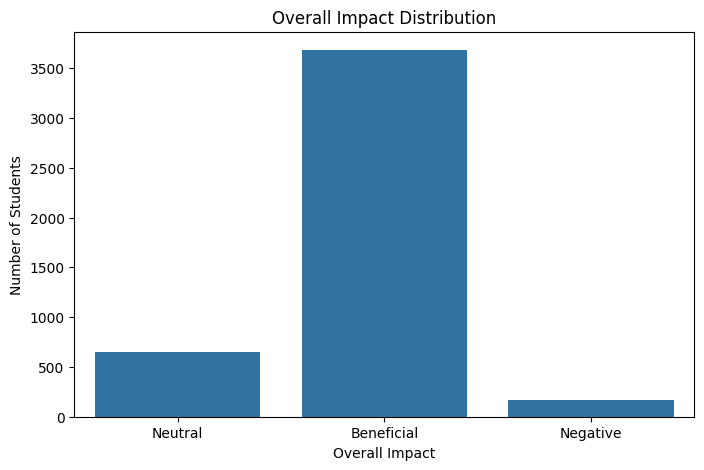

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Overall_Impact")
plt.title("Overall Impact Distribution")
plt.xlabel("Overall Impact")
plt.ylabel("Number of Students")
plt.show()

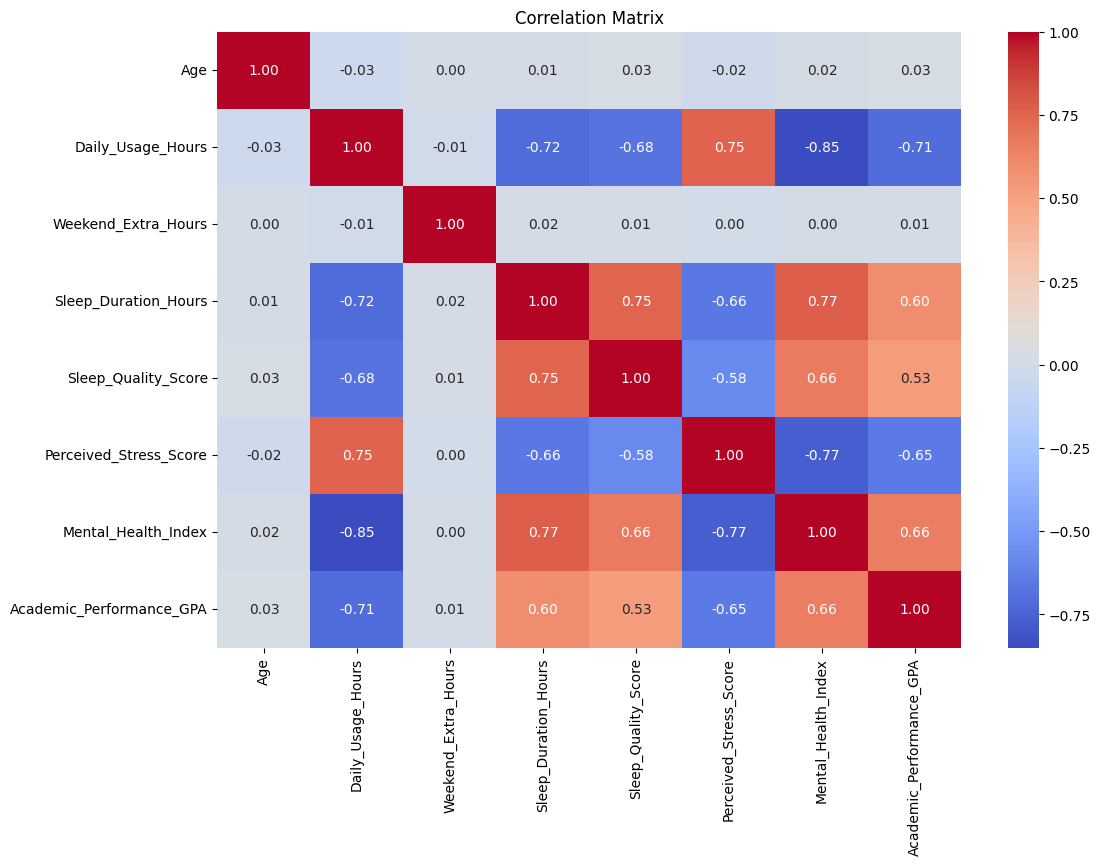

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

Data preprocessing

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["Overall_Impact", "Student_ID"])
y = df["Overall_Impact"]

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['Beneficial' 'Negative' 'Neutral']


In [7]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type', 'Social_Comparison_Frequency']
Numerical: ['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage', 'Perceived_Stress_Score', 'Mental_Health_Index', 'Academic_Performance_GPA']


In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

Train/test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (3600, 14)
Testing: (900, 14)


In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (3600, 31)


Artificial Neural Network

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print(tf.__version__)

2.20.0


Basic ANN model

In [12]:
num_classes = len(np.unique(y_train))
input_dim = X_train_processed.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,227 (16.51 KB)

 Trainable params: 4,227 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

Weights and biases

In [13]:
for layer in model.layers:
    if hasattr(layer, "weights"):
        print("\nLayer:", layer.name)

        for weight in layer.weights:
            print(weight.name, weight.shape)


Layer: dense
kernel (31, 64)
bias (64,)

Layer: dense_1
kernel (64, 32)
bias (32,)

Layer: dense_2
kernel (32, 3)
bias (3,)


Activation functions

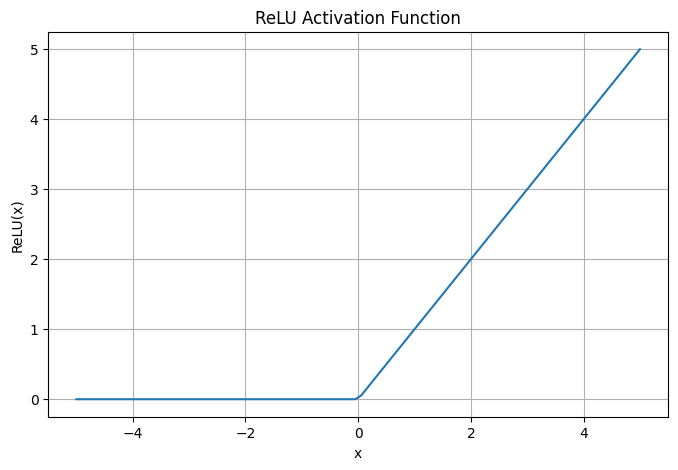

In [14]:
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(8, 5))
plt.plot(x, relu(x))
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid()
plt.show()

Sigmoid

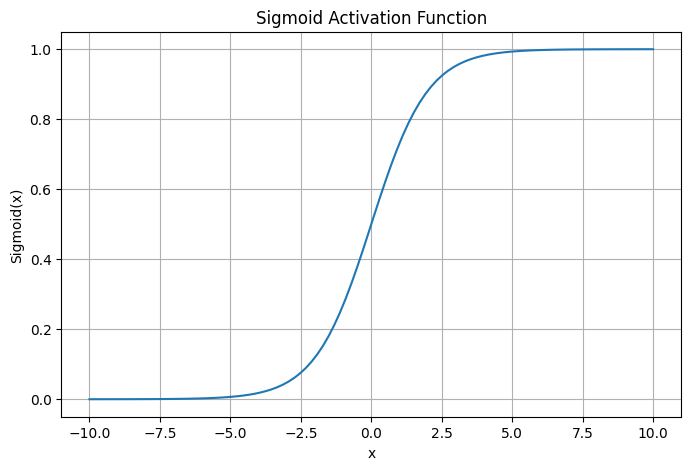

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid(x))
plt.title("Sigmoid Activation Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid()
plt.show()

Tanh

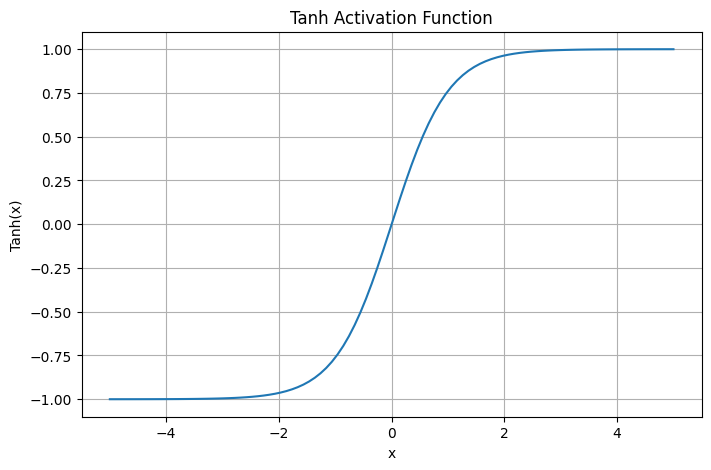

In [16]:
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(8, 5))
plt.plot(x, np.tanh(x))
plt.title("Tanh Activation Function")
plt.xlabel("x")
plt.ylabel("Tanh(x)")
plt.grid()
plt.show()

Forward propagation

In [17]:
sample = X_train_processed[:5]

predictions = model(sample)

print(predictions.numpy())

[[0.18140753 0.23311679 0.5854757 ]
 [0.22675908 0.32051963 0.45272136]
 [0.39302987 0.17053412 0.43643594]
 [0.39297518 0.17332226 0.4337025 ]
 [0.17587395 0.22107212 0.6030539 ]]


In [18]:
predicted_classes = np.argmax(predictions.numpy(), axis=1)

print(predicted_classes)
print(label_encoder.inverse_transform(predicted_classes))

[2 2 2 2 2]
['Neutral' 'Neutral' 'Neutral' 'Neutral' 'Neutral']


Loss function

In [19]:
loss_function = keras.losses.SparseCategoricalCrossentropy()

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
learning_rates = [0.0001, 0.001, 0.01]

for lr in learning_rates:
    print("Learning rate:", lr)

Learning rate: 0.0001
Learning rate: 0.001
Learning rate: 0.01


Stochastic Gradient Descent

In [22]:
from tensorflow.keras.optimizers import SGD

sgd_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_sgd = sgd_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=1,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9382 - loss: 0.1604 - val_accuracy: 0.9681 - val_loss: 0.0820
Epoch 2/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9656 - loss: 0.0805 - val_accuracy: 0.9667 - val_loss: 0.0725
Epoch 3/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9667 - loss: 0.0692 - val_accuracy: 0.9667 - val_loss: 0.0758
Epoch 4/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9733 - loss: 0.0633 - val_accuracy: 0.9583 - val_loss: 0.0885
Epoch 5/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9740 - loss: 0.0580 - val_accuracy: 0.9736 - val_loss: 0.0548
Epoch 6/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9819 - loss: 0.0478 - val_accuracy: 0.9778 - val_loss: 0.0563
Epoch 7/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9795 - loss: 0.0501 - val_accuracy: 0.9750 - val_loss: 0.0553
Epoch 8/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9792 - loss: 0.0488 - 

Mini-batch Gradient Descent

In [24]:
mini_batch_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

mini_batch_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
history_minibatch = mini_batch_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8080 - loss: 0.7000 - val_accuracy: 0.8153 - val_loss: 0.4797
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8608 - loss: 0.3900 - val_accuracy: 0.8667 - val_loss: 0.3388
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8986 - loss: 0.2951 - val_accuracy: 0.8931 - val_loss: 0.2773
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9142 - loss: 0.2477 - val_accuracy: 0.9042 - val_loss: 0.2394
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9233 - loss: 0.2176 - val_accuracy: 0.9222 - val_loss: 0.2130
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9330 - loss: 0.1951 - val_accuracy: 0.9361 - val_loss: 0.1911
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9392 - loss: 0.1766 - val_accuracy: 0.9417 - val_loss: 0.1733
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9455 - loss: 0.1616 - val_accuracy: 0.9569 - val_loss:

Momentum Optimizer

In [26]:
momentum_optimizer = SGD(
    learning_rate=0.01,
    momentum=0.9
)

momentum_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

momentum_model.compile(
    optimizer=momentum_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history_momentum = momentum_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8691 - loss: 0.3246 - val_accuracy: 0.9250 - val_loss: 0.1775
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1304 - val_accuracy: 0.9681 - val_loss: 0.1071
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9701 - loss: 0.0862 - val_accuracy: 0.9681 - val_loss: 0.0819
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9774 - loss: 0.0645 - val_accuracy: 0.9694 - val_loss: 0.0737
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9812 - loss: 0.0549 - val_accuracy: 0.9764 - val_loss: 0.0671
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9847 - loss: 0.0483 - val_accuracy: 0.9694 - val_loss: 0.0669
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9851 - loss: 0.0437 - val_accuracy: 0.9708 - val_loss: 0.0616
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9861 - loss: 0.0405 - val_accuracy: 0.9694 - val_loss:

Adagrad

In [28]:
adagrad_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

adagrad_model.compile(
    optimizer=keras.optimizers.Adagrad(
        learning_rate=0.01
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history_adagrad = adagrad_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8559 - loss: 0.4379 - val_accuracy: 0.8708 - val_loss: 0.3090
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9101 - loss: 0.2487 - val_accuracy: 0.9056 - val_loss: 0.2406
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9201 - loss: 0.2018 - val_accuracy: 0.9181 - val_loss: 0.2023
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9292 - loss: 0.1723 - val_accuracy: 0.9278 - val_loss: 0.1739
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9354 - loss: 0.1500 - val_accuracy: 0.9486 - val_loss: 0.1521
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1332 - val_accuracy: 0.9583 - val_loss: 0.1356
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9576 - loss: 0.1196 - val_accuracy: 0.9583 - val_loss: 0.1239
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9632 - loss: 0.1080 - val_accuracy: 0.9653 - val_loss:

RMSProp

In [30]:
rmsprop_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

rmsprop_model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history_rmsprop = rmsprop_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8576 - loss: 0.3717 - val_accuracy: 0.9125 - val_loss: 0.1874
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9441 - loss: 0.1351 - val_accuracy: 0.9625 - val_loss: 0.1144
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9715 - loss: 0.0883 - val_accuracy: 0.9694 - val_loss: 0.0884
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9774 - loss: 0.0669 - val_accuracy: 0.9750 - val_loss: 0.0720
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9806 - loss: 0.0555 - val_accuracy: 0.9750 - val_loss: 0.0672
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9826 - loss: 0.0492 - val_accuracy: 0.9792 - val_loss: 0.0557
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0439 - val_accuracy: 0.9792 - val_loss: 0.0514
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9861 - loss: 0.0401 - val_accuracy: 0.9792 - val_loss:

Adam Optimizer

In [32]:
adam_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

adam_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history_adam = adam_model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8656 - loss: 0.3821 - val_accuracy: 0.9181 - val_loss: 0.2027
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9503 - loss: 0.1372 - val_accuracy: 0.9583 - val_loss: 0.1121
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9726 - loss: 0.0848 - val_accuracy: 0.9722 - val_loss: 0.0797
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9816 - loss: 0.0620 - val_accuracy: 0.9708 - val_loss: 0.0645
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0502 - val_accuracy: 0.9792 - val_loss: 0.0585
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858 - loss: 0.0448 - val_accuracy: 0.9736 - val_loss: 0.0552
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9885 - loss: 0.0396 - val_accuracy: 0.9806 - val_loss: 0.0488
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0365 - val_accuracy: 0.9792 - val_loss:

Compare optimizers

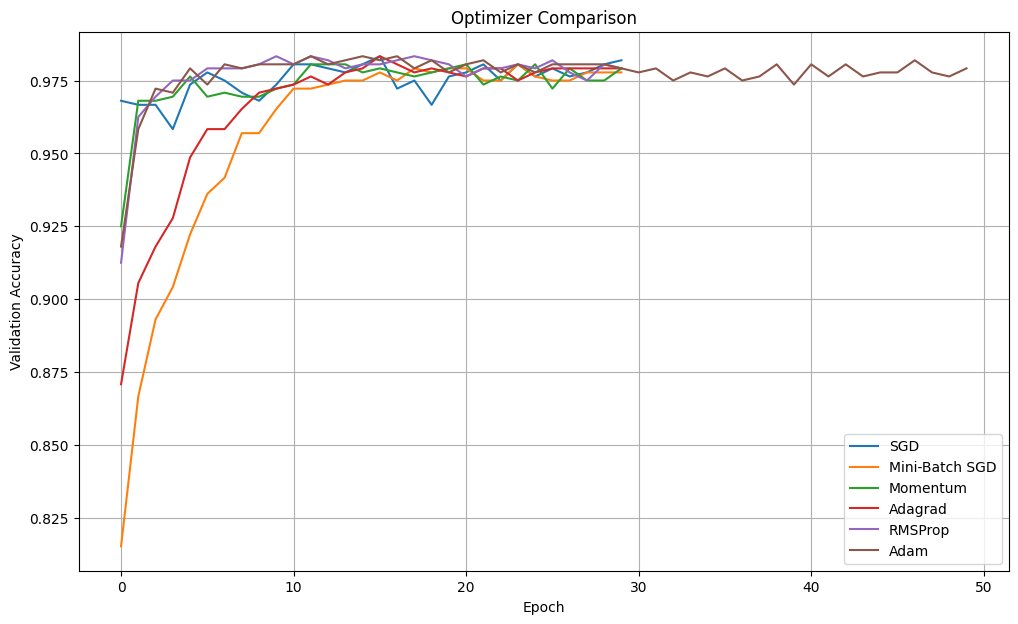

In [34]:
histories = {
    "SGD": history_sgd,
    "Mini-Batch SGD": history_minibatch,
    "Momentum": history_momentum,
    "Adagrad": history_adagrad,
    "RMSProp": history_rmsprop,
    "Adam": history_adam
}

plt.figure(figsize=(12, 7))

for name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

Dropout

In [35]:
dropout_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(num_classes, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
history_dropout = dropout_model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8781 - loss: 0.3352 - val_accuracy: 0.9222 - val_loss: 0.1741
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9441 - loss: 0.1482 - val_accuracy: 0.9667 - val_loss: 0.1001
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9556 - loss: 0.1120 - val_accuracy: 0.9708 - val_loss: 0.0839
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9604 - loss: 0.0957 - val_accuracy: 0.9750 - val_loss: 0.0622
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9691 - loss: 0.0809 - val_accuracy: 0.9764 - val_loss: 0.0612
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9674 - loss: 0.0748 - val_accuracy: 0.9819 - val_loss: 0.0515
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9740 - loss: 0.0687 - val_accuracy: 0.9792 - val_loss: 0.0484
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9743 - loss: 0.0602 - val_accuracy: 0.9792 - val_los

Batch Normalization

In [37]:
batchnorm_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(num_classes, activation="softmax")
])

batchnorm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_batchnorm = batchnorm_model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8604 - loss: 0.3841 - val_accuracy: 0.9528 - val_loss: 0.4180
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9399 - loss: 0.1670 - val_accuracy: 0.9597 - val_loss: 0.2001
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1371 - val_accuracy: 0.9583 - val_loss: 0.1387
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1287 - val_accuracy: 0.9514 - val_loss: 0.1221
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1183 - val_accuracy: 0.9597 - val_loss: 0.1076
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9622 - loss: 0.1022 - val_accuracy: 0.9653 - val_loss: 0.1032
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9684 - loss: 0.0900 - val_accuracy: 0.9611 - val_loss: 0.1039
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9642 - loss: 0.0909 - val_accuracy: 0.9583 - val_loss

L1 Regularization

In [39]:
l1_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001)
    ),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001)
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

l1_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

L2 Regularization

In [40]:
l2_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

l2_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Combined regularization model

In [41]:
final_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.30),

    layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.20),

    layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

final_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,299 (59.76 KB)

 Trainable params: 14,915 (58.26 KB)

 Non-trainable params: 384 (1.50 KB)

Early stopping

In [44]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [46]:
final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [48]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [50]:
import tensorflow as tf

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [55]:
import tensorflow as tf

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseCategoricalAccuracy(name="categorical_accuracy")
    ]
)

In [56]:
history_final = final_model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8316 - categorical_accuracy: 0.8316 - loss: 0.5876 - val_accuracy: 0.9208 - val_categorical_accuracy: 0.9208 - val_loss: 0.5617
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9153 - categorical_accuracy: 0.9153 - loss: 0.3847 - val_accuracy: 0.9431 - val_categorical_accuracy: 0.9431 - val_loss: 0.3745
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9229 - categorical_accuracy: 0.9229 - loss: 0.3494 - val_accuracy: 0.9583 - val_categorical_accuracy: 0.9583 - val_loss: 0.3131
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9222 - categorical_accuracy: 0.9222 - loss: 0.3175 - val_accuracy: 0.9681 - val_categorical_accuracy: 0.9681 - val_loss: 0.2775
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9340 - categorical_accuracy: 0.9340 - loss: 0.2944 - val_accuracy: 0.9611 - val_categorical_accuracy: 0.9611 - val_loss: 0.2604
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━

Plot training performance

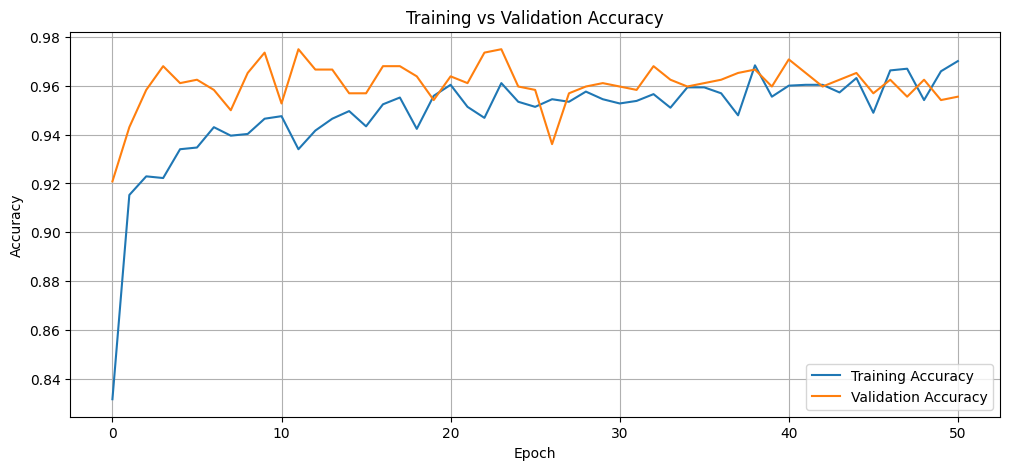

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_final.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_final.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

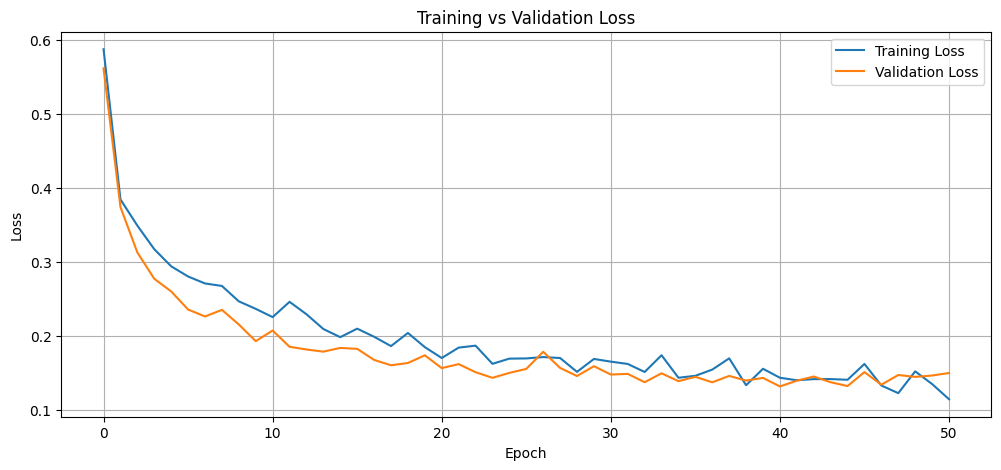

In [58]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_final.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_final.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Evaluate the model

In [60]:
results = final_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(results)

[0.13710863888263702, 0.9611111283302307, 0.9611111283302307]


In [61]:
print(final_model.metrics_names)

['loss', 'compile_metrics']


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import numpy as np

# Predictions
y_pred_prob = final_model.predict(X_test_processed)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Multiclass AUC
auc = roc_auc_score(
    y_test,
    y_pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("===== FINAL MODEL RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
===== FINAL MODEL RESULTS =====
Accuracy : 0.9611
Precision: 0.9614
Recall   : 0.9611
F1 Score : 0.9613
AUC-ROC  : 0.9947


Classification report

In [64]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_probability = final_model.predict(
    X_test_processed
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

  Beneficial       0.98      0.98      0.98       736
    Negative       0.91      0.88      0.89        33
     Neutral       0.86      0.88      0.87       131

    accuracy                           0.96       900
   macro avg       0.92      0.91      0.91       900
weighted avg       0.96      0.96      0.96       900



Confusion matrix

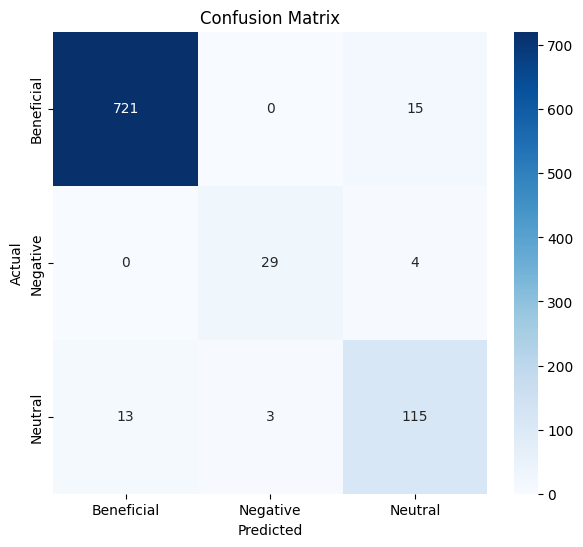

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Hyperparameter tuning

In [66]:
def build_model(
    units1=128,
    units2=64,
    dropout_rate=0.2,
    learning_rate=0.001
):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(
            units1,
            activation="relu"
        ),

        layers.Dropout(dropout_rate),

        layers.Dense(
            units2,
            activation="relu"
        ),

        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [67]:
experiments = [
    {
        "units1": 64,
        "units2": 32,
        "dropout_rate": 0.2,
        "learning_rate": 0.001
    },
    {
        "units1": 128,
        "units2": 64,
        "dropout_rate": 0.2,
        "learning_rate": 0.001
    },
    {
        "units1": 128,
        "units2": 64,
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "units1": 256,
        "units2": 128,
        "dropout_rate": 0.3,
        "learning_rate": 0.0005
    }
]

In [68]:
results = []

for params in experiments:

    model = build_model(**params)

    history = model.fit(
        X_train_processed,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test_processed,
        y_test,
        verbose=0
    )

    results.append({
        **params,
        "test_loss": loss,
        "test_accuracy": accuracy
    })

results_df = pd.DataFrame(results)

display(results_df)

,units1,units2,dropout_rate,learning_rate,test_loss,test_accuracy
0,64,32,0.2,0.0010,0.063085,0.973333
1,128,64,0.2,0.0010,0.064166,0.975556
2,128,64,0.3,0.0010,0.069309,0.974444
3,256,128,0.3,0.0005,0.068547,0.974444


In [69]:
results = []

for params in experiments:

    model = build_model(**params)

    history = model.fit(
        X_train_processed,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test_processed,
        y_test,
        verbose=0
    )

    results.append({
        **params,
        "test_loss": loss,
        "test_accuracy": accuracy
    })

results_df = pd.DataFrame(results)

display(results_df)

,units1,units2,dropout_rate,learning_rate,test_loss,test_accuracy
0,64,32,0.2,0.0010,0.066448,0.981111
1,128,64,0.2,0.0010,0.067540,0.975556
2,128,64,0.3,0.0010,0.068779,0.973333
3,256,128,0.3,0.0005,0.069285,0.974444


In [70]:
final_model.save("social_media_impact_ann.keras")

In [71]:
import joblib

joblib.dump(
    preprocessor,
    "social_media_preprocessor.pkl"
)

joblib.dump(
    label_encoder,
    "social_media_label_encoder.pkl"
)

['social_media_label_encoder.pkl']

In [72]:
new_student = pd.DataFrame({
    "Age": [20],
    "Gender": ["Male"],
    "Academic_Level": ["Undergraduate"],
    "Primary_Platform": ["Instagram"],
    "Daily_Usage_Hours": [5.0],
    "Weekend_Extra_Hours": [2.0],
    "Device_Type": ["Smartphone"],
    "Sleep_Duration_Hours": [7.0],
    "Sleep_Quality_Score": [4],
    "Late_Night_Usage": [False],
    "Social_Comparison_Frequency": ["Sometimes"],
    "Perceived_Stress_Score": [12.0],
    "Mental_Health_Index": [80],
    "Academic_Performance_GPA": [3.4]
})

In [73]:
new_student_processed = preprocessor.transform(
    new_student
)

In [74]:
probabilities = final_model.predict(
    new_student_processed
)

predicted_class = np.argmax(
    probabilities,
    axis=1
)

predicted_label = label_encoder.inverse_transform(
    predicted_class
)

print("Predicted Overall Impact:", predicted_label[0])

print("\nProbabilities:")

for label, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):
    print(f"{label}: {probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted Overall Impact: Beneficial

Probabilities:
Beneficial: 0.9996
Negative: 0.0000
Neutral: 0.0004
